# Age Estimation and Gender Classification

In this assignment, you will train CNN models to estimate a person's age and predict their gender based on face images. Please read carefully all the instructions before you start to write your code.

**Your Tasks**

You are supposed to train two CNN models.
- Model A: Train a CNN model from scratch, following a few restrictions. Save this model as `age_gender_A.keras`
- Model B: Fine-tune a pre-trained model to perform the same task. Save this model as `age_gender_B.keras`

**Dataset**

Your models will be trained and validated on a folder `train_val/` containing 5,000 labeled face images (size: 128 x 128), originated from the UTKFace dataset. During the assessment phase, your code will be tested on unseen test data.

**Performance Metric**

The evaluation of your models on the test set will be based on the following metrics:
- age estimation: - Mean Absolute Error (MAE)
- gender prediction: accuracy

**GPU Time Management**

Please use the available GPU time wisely, as there are some limitations on free GPU usage. It is said the users can use up to 12 hours in row in Google Colab. But many people found they reached its limit far less than 12 hours. To minimize the risk of reaching the limit, consider the following suggestions:
1. Ensure you have a stable internet connection.
2. Carefully validate your hyperparameters before starting the training process.
3. Based on past experience, each model should be trained in less than 2 hours. If the training time is significantly longer, you may need to adjust your model architecture.


## Setting Up: Mount the google drive
Mount your google drive to the notebook. Also don't forget to **enable GPU** before your training.


In [1]:
#

# Add your code here
from google.colab import drive
drive.mount('/content/drive')

#

Mounted at /content/drive


## Visualize a few photos
It's always beneficial to thoroughly understand your data before beginning the training process. To get a first-hand impression of the dataset, please display a minimum of 20 images from the `train_val/` folder, along with their corresponding age and gender labels. This will help you gain initial insights into the dataset.

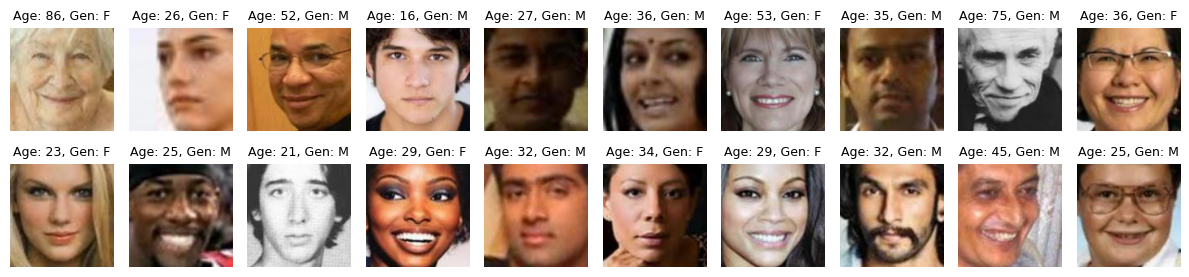

In [1]:
#

# Add your code here
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

folder = 'train_val/'
file_list = os.listdir(folder)

plt.figure(figsize=(12,3))

for i in range(20):
  filename = file_list[i]

  split = filename.split('_')

  age = split[0]
  gender = 'M' if split[1] == '0' else 'F'
  image = imread(os.path.join(folder,filename))

  plt.subplot(2,10,i+1)
  plt.title(f'Age: {age}, Gen: {gender}', fontsize=9)
  plt.imshow(image)
  plt.axis('off')

plt.tight_layout()
plt.show()

#

## Step 1: Data Pre-Processing
In this step, you will perform necessary pre-processing tasks before feeding the data into a CNN. The pre-processing includes:

1. Splitting the data into training and validation sets.
2. Loading image data, gender labels and age values, and rescaling pixel values (originally integers between 0 and 255) to the range [0, 1].
3. Data augmentation

The first two pre-processing steps have already been completed for you. Your task in this step is limited to:

3. Data augmentation

Please note:

- Do not modify any part of the provided code except the section marked with ########.
- Do not rescale the age values to the range [0,1], as the original values are used during the testing stage. Rescaling them would significantly impact testing performance.



Number of images for training: 4000
Number of images for validation: 1000
load all image data, age and gender labels...
load all image data, age and gender labels...


2025-12-04 02:04:37.916765: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2025-12-04 02:04:37.916897: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-04 02:04:37.916901: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-04 02:04:37.917051: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-04 02:04:37.917080: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


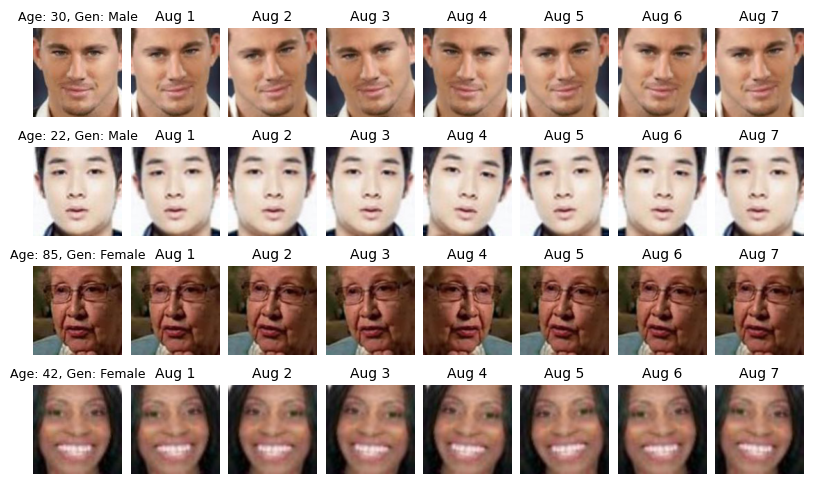

In [2]:
import os
import random
import numpy as np

import cv2

folder_train_val = 'train_val/'
all_image_files = [file for file in os.listdir(folder_train_val) if file.lower().endswith(('.jpg'))]

# Shuffle the dataset to ensure random distribution
random.seed(0)  # Ensure reproducibility
random.shuffle(all_image_files)

# Calculate the number of images for each set
n_train_val = len(all_image_files)
train_end = int(n_train_val * 0.8)

# Split the dataset
train_image_files = all_image_files[:train_end]
val_image_files = all_image_files[train_end:]
print(f"Number of images for training: {len(train_image_files)}")
print(f"Number of images for validation: {len(val_image_files)}")

def load_imgs_lables(dataset_path,filenames):
  print('load all image data, age and gender labels...')
  images = []
  age_labels = []
  gender_labels = []
  for current_file_name in filenames:
    img = cv2.imread(os.path.join(dataset_path, current_file_name))
    img = img / 255.0  # Normalize pixel values
    labels = current_file_name.split('_')
    age_label = int(labels[0])
    gender_label = int(labels[1])
    age_labels.append(age_label)
    gender_labels.append(gender_label)
    images.append(img)

  # Convert to NumPy arrays
  images = np.array(images)
  age_labels = np.array(age_labels)
  gender_labels = np.array(gender_labels)
  return images, age_labels, gender_labels

# load data from the training set
train_images, train_age, train_gender = load_imgs_lables(folder_train_val,train_image_files)

# load data from the validation set
val_images, val_age, val_gender = load_imgs_lables(folder_train_val,val_image_files)

#

######### Add your code for data augmentation here #########
import tensorflow as tf
from tensorflow.keras import layers, Sequential

import matplotlib.pyplot as plt

data_augmentation = Sequential([layers.RandomFlip('horizontal'),
                                layers.RandomRotation(0.03),
                                layers.RandomZoom(0.01)
                                ])

# Creating Datasets using tensor slices fro training and validation data
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, {'age': train_age, 'gender': train_gender})
)
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_images, {'age': val_age, 'gender': val_gender})
)

# Augmentation for training data only. can toggle augmentation on or off
augmentation_on = True
AUTOTUNE = tf.data.AUTOTUNE

aug_train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=augmentation_on), y),
    num_parallel_calls = AUTOTUNE
)
aug_train_dataset.shuffle(len(train_images))

aug_train_dataset = (aug_train_dataset.batch(32).prefetch(buffer_size=AUTOTUNE))
aug_val_dataset = (val_dataset.batch(32).prefetch(buffer_size=AUTOTUNE))

# Visualising the extent of augmentation
num_images = 4
no_iterations = 7

index_list = np.random.choice(len(train_images), num_images, replace=False)
unaugmented_images = train_images[index_list]

age_label = train_age[index_list]
age_label = [str(i) for i in age_label]
gender_label = train_gender[index_list]
gender_label = ['Male' if label == 0 else 'Female' for label in gender_label]

# to visualise the images need to swap colours, not doing to the actural validation data_set
unaugmented_images = unaugmented_images[..., ::-1]

augmented_list = []
for image in unaugmented_images:
  empty_list = []
  empty_list.append(image)

  for _ in range(no_iterations):
    empty_list.append(data_augmentation(image, training=True))

  augmented_list.append(empty_list)

plt.figure(figsize=(8,5))

for row in range(num_images):
  for col in range(no_iterations+1):

    index = row*(no_iterations+1) + col + 1
    plt.subplot(num_images, no_iterations+1, index)
    plt.imshow(augmented_list[row][col])

    if col==0:
      age = age_label[row]
      gender = gender_label[row]
      plt.title(f'Age: {age}, Gen: {gender}', fontsize=9)
    else:
      plt.title(f'Aug {col}', fontsize=10)

    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.show()

# aside for visualising the data distribution
# import pandas as pd
# import numpy as np

# train_labels = ['Male' if g == 0 else 'Female' for g in train_gender]
# val_labels   = ['Male' if g == 0 else 'Female' for g in val_gender]

# s_train = pd.Series(train_labels)
# s_val   = pd.Series(val_labels)

# gender_table = pd.DataFrame({
#     'Train Count': s_train.value_counts(),
#     'Train %':     s_train.value_counts(normalize=True) * 100,
#     'Val Count':   s_val.value_counts(),
#     'Val %':       s_val.value_counts(normalize=True) * 100
# })
# print(gender_table)
# print("\n")


# bins = range(0, 121, 10)
# train_binned = pd.cut(train_age, bins=bins)
# val_binned   = pd.cut(val_age, bins=bins)

# age_table = pd.DataFrame({
#     'Train Count': train_binned.value_counts(),
#     'Val Count':   val_binned.value_counts()
# })

# print(age_table)

#

## STEP2A: Build your own CNN network
In this step, you will define your own CNN model for identifying gender and predicting age. Although there are two tasks, you only need to build one CNN model with two outputs. You may refer to online resources for solutions.

Here are the key requirements and restrictions for your network:
1.	The input size must be 128 x 128 x 3, which means you **should not resize** the original images. This is because my test code relies on this particular input size. Any other size will cause problem in the testing stage.
2.  Please treat the gender classification as a binary problem, i.e., **the output layer for the gender branch has only 1 unit**, instead of 2. Although it is technically correct to treat gender classification as a multi-class problem with 2 classes, i.e., 2 units in the last layer, the test code only supports a 1-unit last-layer configuration for the gender branch.
3.	The size of feature maps being fed to the first fully connected layer must be less than 10 x 10, while there is no number limitation about the depth.
4.	Incorporate techniques to prevent overfitting as appropriate.

At the end of your implementation, use `modelA.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.

In [3]:
#

# Add your code here
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2

dropouts = [0.10, 0.15, 0.15, 0.20]
filters = [32, 64, 128, 256]

inputs = layers.Input(shape=(128, 128, 3))
block = inputs

# Shared layers
for dropout, filter in zip(dropouts, filters):
  block = layers.Conv2D(filter, 3, padding='same', activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(block)
  block = layers.BatchNormalization()(block)

  block = layers.Conv2D(filter, 3, padding='same', activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(block)
  block = layers.BatchNormalization()(block)

  block = layers.MaxPooling2D()(block)
  block = layers.Dropout(dropout)(block)

block = layers.GlobalAveragePooling2D()(block)
block = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(block)
block = layers.Dropout(0.4)(block)

# gender branch
g = layers.Dense(128, activation='relu', kernel_initializer='he_normal')(block)
g = layers.Dropout(0.35)(g)
gender = layers.Dense(1, activation='sigmoid', name='gender')(g)

# age branch
a = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(block)
a = layers.Dropout(0.25)(a)

a = layers.Dense(128, activation='relu', kernel_initializer='he_normal')(a)
a = layers.Dropout(0.1)(a)
age = layers.Dense(1, name='age')(a)

modelA = Model(inputs, [age, gender])
#

modelA.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelA, show_shapes=True,dpi=100)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]  

 Total params: 1,537,826 (5.87 MB)

 Trainable params: 1,535,906 (5.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## STEP3A: Compile and train your model
Compile and train your model here.
Save your model by `modelA.save(your_model_folder+"age_gender_A.keras")` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Save the model with `save()`** to save the entire model (including a model's architecture, weights, and training configuration) as a `.keras` zip archive. Don't save it with `save_weights()`.


In [ ]:
#

# Add your code here
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

import os

modelA.compile(optimizer=Adam(learning_rate=3.5e-4),
               loss = {'age': 'mae', 'gender': 'binary_crossentropy'},
               loss_weights = {'age': 0.6, 'gender': 0.4},
               metrics = {'age': 'mae', 'gender': 'accuracy'})

adjust_LR = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.5,
                              patience = 5,
                              min_lr = 1e-6,
                              verbose = 1)

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 12,
                           restore_best_weights = True,
                           verbose = 1)

modelA_history = modelA.fit(aug_train_dataset,
                           validation_data = aug_val_dataset,
                           epochs = 70,
                           callbacks = [early_stop, adjust_LR],
                           verbose = 1)

folder_models = "/content/drive/MyDrive/Colab Notebooks/Understanding Deep Learning Coursework/models/"
os.makedirs(folder_models, exist_ok=True)

#
modelA.save(folder_models+'age_gender_A.keras')

Epoch 1/70


2025-12-04 02:05:12.363075: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - age_loss: 15.7808 - age_mae: 15.7808 - gender_accuracy: 0.5520 - gender_loss: 1.4904 - loss: 10.2568 - val_age_loss: 19.1396 - val_age_mae: 19.1650 - val_gender_accuracy: 0.4690 - val_gender_loss: 1.0292 - val_loss: 12.1043 - learning_rate: 3.5000e-04
Epoch 2/70
 91/125 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - age_loss: 15.6782 - age_mae: 15.6782 - gender_accuracy: 0.5657 - gender_loss: 1.3828 - loss: 10.1522

## STEP4A: Draw the learning curves
Draw four learning curve figures for model A as follows.
1.	The loss of the gender classification over the training and validation set
2.	The accuracy of the gender classification over the training and validation set
3.	The loss of the age estimation over the training and validation set
4.	The MAE of the age estimation over the training and validation set

val_gender_loss
val_gender_accuracy
val_age_loss
val_age_mae


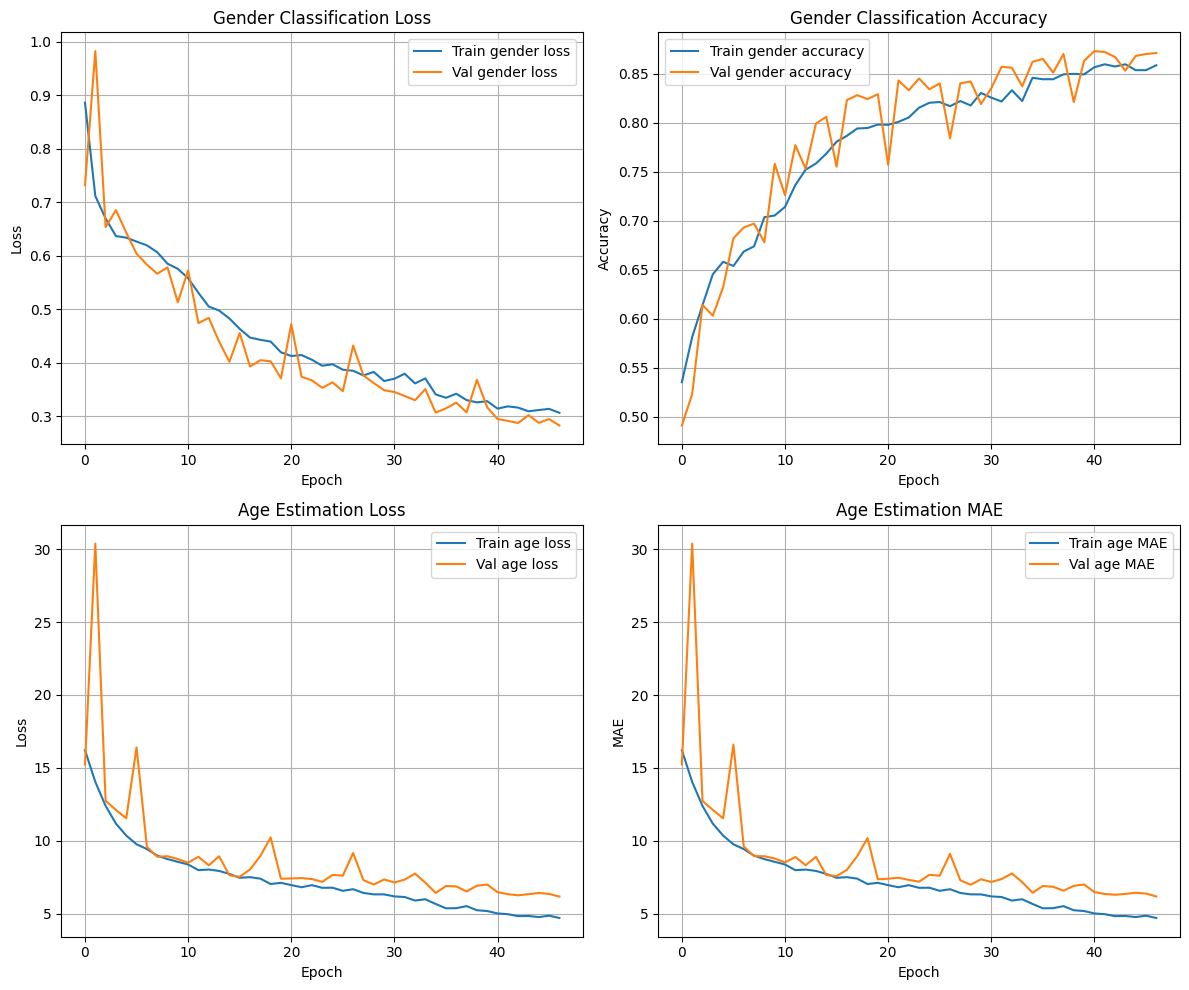

In [33]:
#

# Add your code here
import matplotlib.pyplot as plt

history = modelA_history.history

# determine the epochs to print
best_epoch = int(np.argmin(history['val_loss']))
epochs = best_epoch + 1

plt.figure(figsize=(12,10))

labels = ['gender loss', 'gender accuracy', 'age loss', 'age MAE']
keys = ['gender_loss', 'gender_accuracy', 'age_loss', 'age_mae']
ylabels = ['Loss', 'Accuracy', 'Loss', 'MAE']
titles = ['Gender Classification Loss', 'Gender Classification Accuracy', 'Age Estimation Loss', 'Age Estimation MAE']


for index, (label, key, ylabel, title) in enumerate(zip(labels, keys, ylabels, titles), start = 1):

  plt.subplot(2,2,index)
  plt.plot(history[key][:epochs], label='Train ' + label)
  plt.plot(history['val_' + key][:epochs], label='Val ' + label)
  print('val_'+key)

  plt.xlabel('Epoch')
  plt.ylabel(ylabel)
  plt.title(title)
  plt.legend()
  plt.grid(True)

plt.tight_layout()
plt.show()

#


## STEP2B: Build a CNN network based on a pre-trained model
Choose an existing CNN architecture pre-trained on ImageNet and fine-tune it on this dataset.

As with Model A, **do not resize the input image size**.
Ensure that the output layer for **the gender branch has only 1 unit**.

At the end of the cell, use `modelB.summary()` to display the model architecture and use `plot_model()` to visualize the architecture.


Model: "VGG16_pretrained_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer_9[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 15,175,746 (57.89 MB)

 Trainable params: 460,546 (1.76 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

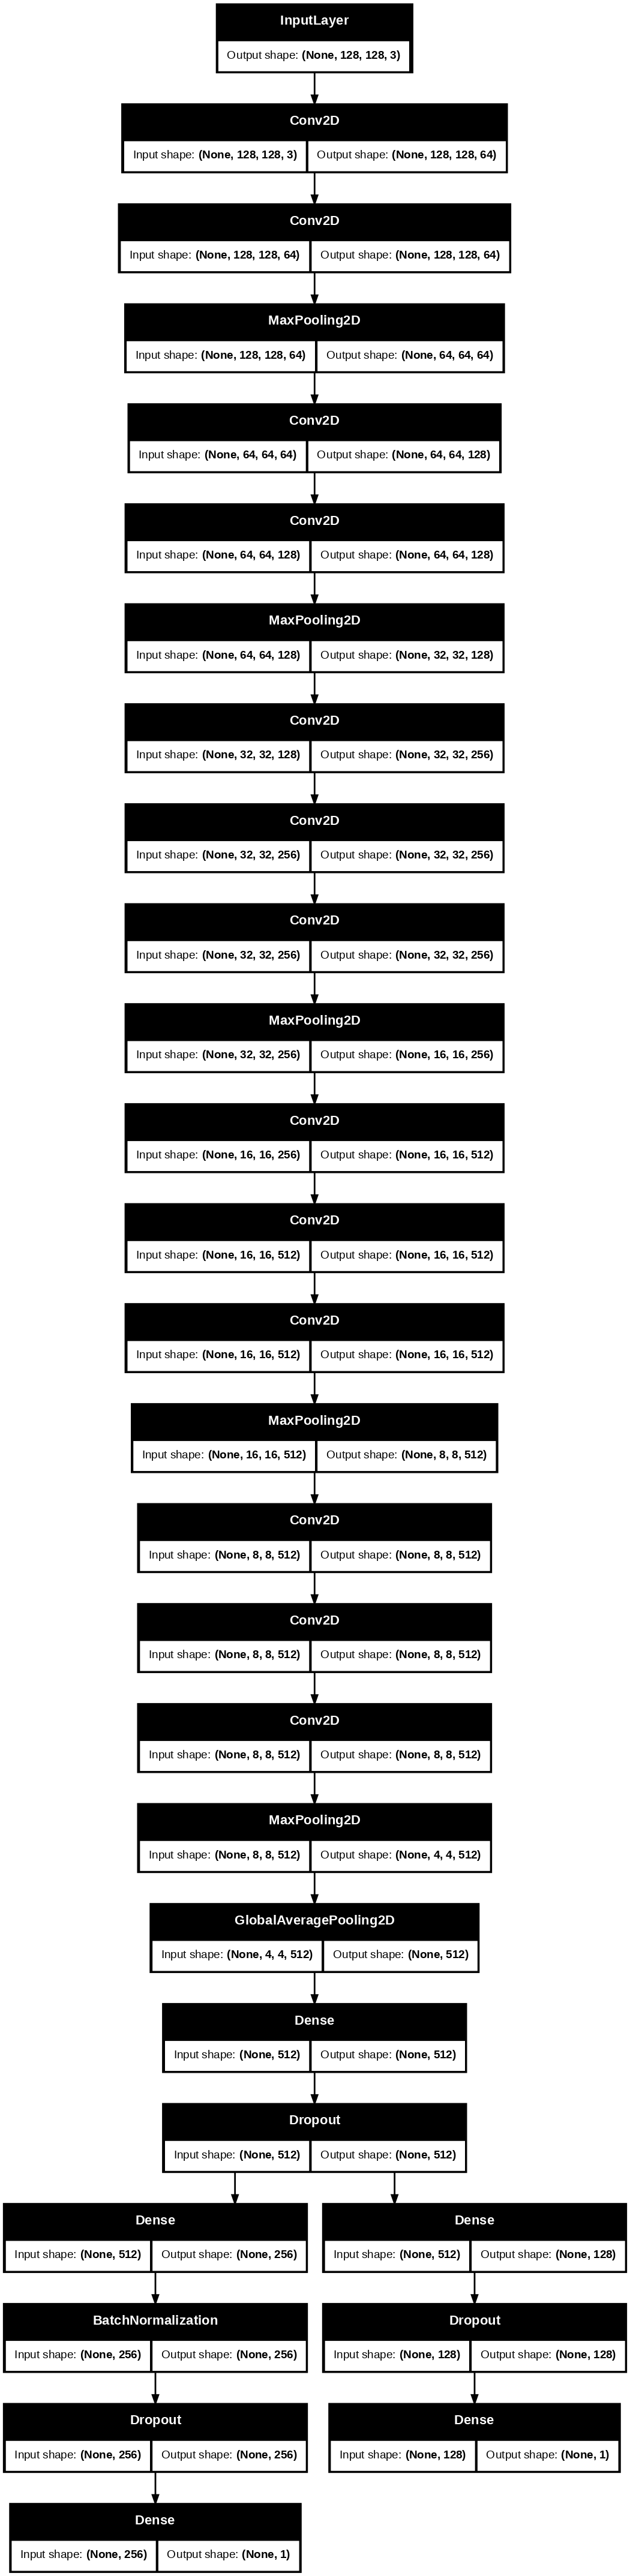

In [17]:
#

# Add your code here
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(128, 128, 3))

imported_model = VGG16(weights = 'imagenet',
                          include_top = False,
                          input_tensor = inputs)

imported_model.trainable = False

model = imported_model.output
model = layers.GlobalAveragePooling2D()(model)
model = layers.Dense(512, activation='relu')(model)
model = layers.Dropout(0.4)(model)

# gender branch
g = layers.Dense(128, activation='relu', kernel_initializer='he_normal')(model)
g = layers.Dropout(0.35)(g)
gender = layers.Dense(1, activation='sigmoid', name='gender')(g)

# age branch
a = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(model)
a = layers.BatchNormalization()(a)
a = layers.Dropout(0.3)(a)
age = layers.Dense(1, name='age')(a)

modelB = Model(inputs = inputs,
               outputs = [age, gender],
               name = 'VGG16_pretrained_model')
#

modelB.summary()
from tensorflow.keras.utils import plot_model
plot_model(modelB, show_shapes=True,dpi=100)

## STEP3B: Compile and train your model
Compile and train your model here.
Save your model to `age_gender_B.keras` after training.

**DON'T use any other name for your model file.** This is because my test code relies on this particular model name. Any other file name will cause problem in the testing stage.

**Also, save the model with `save()` instead of `save_weights()`.**


In [18]:
#

# Add your code here
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

modelB.compile(optimizer=Adam(learning_rate=5e-4),
               loss = {'age': 'mae', 'gender': 'binary_crossentropy'},
               loss_weights = {'age':0.65, 'gender': 0.35},
               metrics = {'age': ['mae'], 'gender': ['accuracy']})

adjust_LR_1 = ReduceLROnPlateau(monitor = 'val_loss',
                              min_delta = 2e-3,
                              factor = 0.5,
                              patience = 2,
                              min_lr = 1e-6,
                              verbose = 1)

early_stop_1 = EarlyStopping(monitor = 'val_loss',
                           patience = 3,
                           min_delta = 2e-3,
                           restore_best_weights = True,
                           verbose = 1)

# First training stage
history_stage_1 = modelB.fit(aug_train_dataset,
                           validation_data = aug_val_dataset,
                           epochs = 20,
                           callbacks = [adjust_LR_1, early_stop_1],
                           verbose = 1)

# Finetuning top layers
imported_model.trainable = True
for layer in imported_model.layers[:7]:
  layer.trainable = False

modelB.compile(optimizer=Adam(learning_rate=1e-4),
               loss = {'age': 'mae', 'gender': 'binary_crossentropy'},
               loss_weights = {'age':0.4, 'gender': 0.6},
               metrics = {'age': ['mae'], 'gender': ['accuracy']})


adjust_LR_2 = ReduceLROnPlateau(monitor = 'val_loss',
                                min_delta = 2e-3,
                                factor = 0.50,
                                patience = 3,
                                min_lr = 1e-7,
                                verbose = 1)

early_stop_2 = EarlyStopping(monitor = 'val_loss',
                             min_delta = 2e-3,
                             patience = 10,
                             restore_best_weights = True,
                             verbose = 1)

# Second training stage
history_stage_2 = modelB.fit(aug_train_dataset,
                           validation_data = aug_val_dataset,
                           epochs = 70,
                           callbacks = [adjust_LR_2, early_stop_2],
                           verbose = 1)

your_model_folder = "/content/drive/MyDrive/Colab Notebooks/Understanding Deep Learning Coursework/models/"

#

modelB.save(your_model_folder+"age_gender_B.keras")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - age_loss: 32.6290 - age_mae: 32.6290 - gender_accuracy: 0.5190 - gender_loss: 0.7112 - loss: 21.4578 - val_age_loss: 31.3292 - val_age_mae: 31.3106 - val_gender_accuracy: 0.7100 - val_gender_loss: 0.6075 - val_loss: 20.5650 - learning_rate: 5.0000e-04
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - age_loss: 30.6319 - age_mae: 30.6319 - gender_accuracy: 0.6468 - gender_loss: 0.6361 - loss: 20.1333 - val_age_loss: 26.4885 - val_age_mae: 26.4862 - val_gender_accuracy: 0.7430 - val_gender_loss: 0.5572 - val_loss: 17.4116 - learning_rate: 5.0000e-04
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - age_loss: 26.0735 - age_mae: 26.0735 - gender_accuracy: 0.6756 - gender_loss: 0.6089 - loss: 17.1609 - val_age_loss: 16.2838 - val_age_mae: 16.3585 - val_gender_accuracy: 0.7400 - val_gender_loss: 0.5441 - val_loss: 10.8241 - learning_rate: 5.0000e-04
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - age_loss: 18.4708 -

## STEP4B: Draw the learning curves
Draw four learning curve figures for model B as follows.
1. The loss of the gender classification over the training and validation set
2. The accuracy of the gender classification over the training and validation set
3. The loss of the age estimation over the training and validation set
4. The MAE of the age estimation over the training and validation set

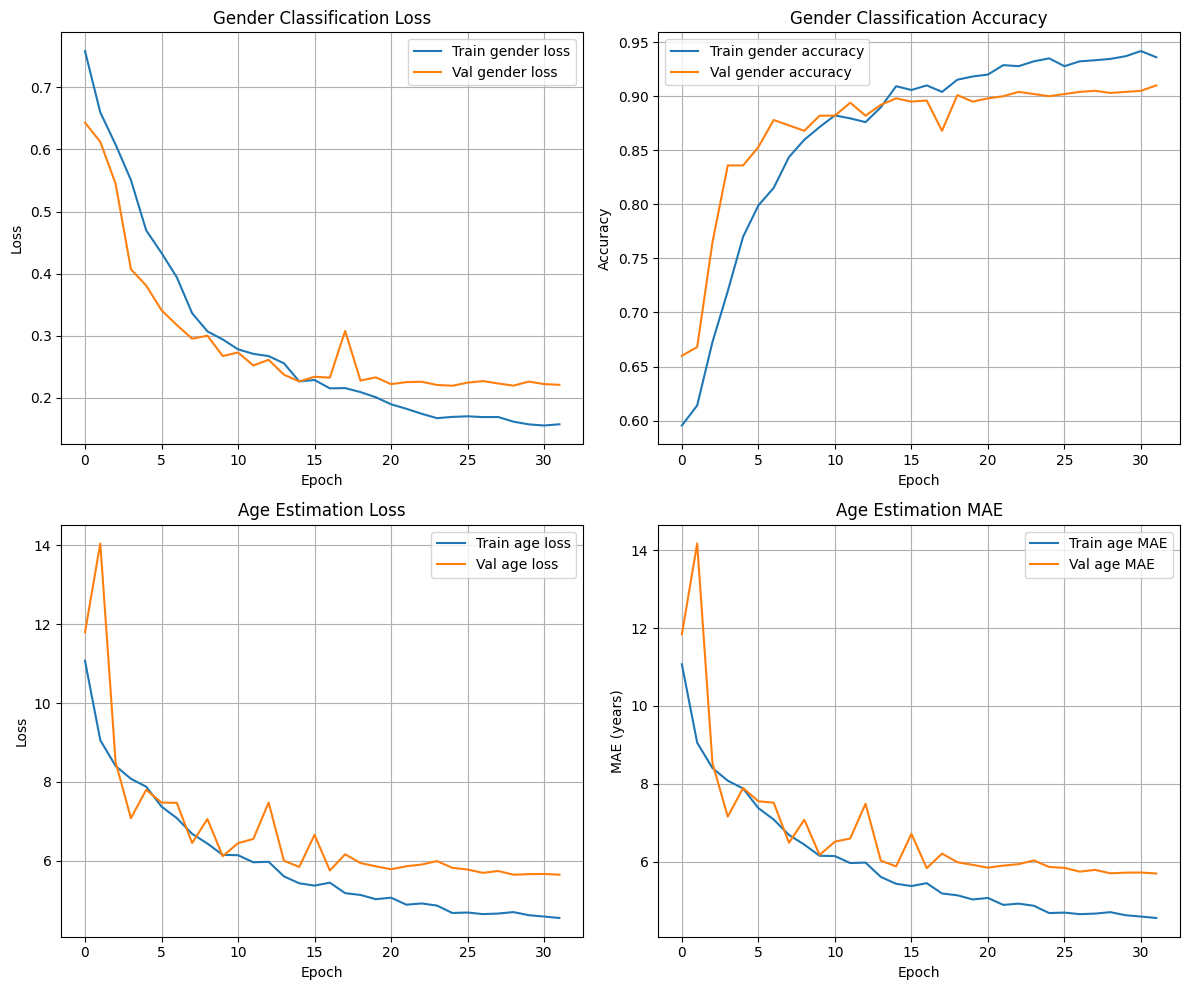

In [29]:
#
# Add your code here
import numpy as np
import matplotlib.pyplot as plt

# Use second-stage history
history = history_stage_2.history

# determine the epochs to plot (best epoch based on val_loss)
best_epoch = int(np.argmin(history['val_loss']))
epochs = best_epoch

plt.figure(figsize=(12, 10))

labels  = ['gender loss', 'gender accuracy', 'age loss', 'age MAE']
keys    = ['gender_loss', 'gender_accuracy', 'age_loss', 'age_mae']
ylabels = ['Loss', 'Accuracy', 'Loss', 'MAE (years)']
titles  = ['Gender Classification Loss', 'Gender Classification Accuracy', 'Age Estimation Loss', 'Age Estimation MAE']

for index, (label, key, ylabel, title) in enumerate(zip(labels, keys, ylabels, titles), start=1):

    plt.subplot(2, 2, index)
    plt.plot(history[key][:epochs], label='Train ' + label)
    plt.plot(history['val_' + key][:epochs], label='Val ' + label)

    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

#


## STEP5: Evaluate the model on the test set
I will load your two models for testing. The test set will not be available before your submission.

The metrics for measuring the performance on the test set are:
- age estimation: MAE (Mean Absolute Error)
- gender classification: accuracy


In [ ]:
#
# Don't add code in this cell when submitting this file
#